# Coordination and Resource Allocation Under Water Scarcity During Heatwaves: An LLM-Based Multi-Agent Simulation

This simulation models **institutional stakeholders negotiating over a shared, shrinking water supply** during a severe multi-day heatwave in Germany.

**Research question:** how do autonomous LLM-based agents coordinate the allocation of scarce water resources during a heatwave — when do they cooperate, compete, and adapt?


### What lives where

| Mechanism | Location |
|---|---|
| LLM helpers, cache, cost tracker | `water_scarcity_sim.py` §1 |
| Water supply schedule + demand escalation | §2 |
| Stakeholder profiles + negotiation topology | §3 |
| Negotiation protocol + deterministic clearing | §4 |
| Memory stream + importance + retrieval | §5 |
| Reflection on importance threshold | §6 |
| Need estimation / negotiation moves / authority ruling | §7 |
| `RunConfig`, simulation engine, `run_batch`, metrics | §8 |

Design principle: **use arithmetic deterministic** (supply, demand, allocation clearing, metrics) and let the LLM decide *behavior* on top of it — what to request, how to argue, whether to concede. The clearing function, not any LLM call, is what guarantees allocations never exceed supply.

**Experiment contract:** every `run_simulation(config)` call returns exactly `(decisions_df, outcomes_df, agents)` — process-level moves, outcome-level results, and memory streams for qualitative drill-down. Everything you'd want to vary between experimental conditions (supply schedule, negotiation cap, priority weights, demand level, seed) lives in a `RunConfig`, so sweeping conditions means constructing several `RunConfig`s and calling `run_batch()` — never editing module constants between runs.


In [1]:
import water_scarcity_sim as sim
import pandas as pd
import matplotlib.pyplot as plt


---
## 1. Stakeholders and negotiation topology

Seven institutional stakeholders: one arbiter (the Water Authority), five demanders, and one advocate (the Environmental Protection Agency, which argues for an ecological reserve rather than consuming water itself).


In [2]:
for s in sim.STAKEHOLDERS:
    print(f'{s.id:16} role={s.role:9} priority_weight={s.priority_weight}')

print('\nNegotiation topology (peer-to-peer trade links, in addition to the implicit hub link '
      'every demander has to the Water Authority):')
for k, v in sim.NEGOTIATION_TOPOLOGY.items():
    if v:
        print(f'  {k} <-> {v}')


water_authority  role=arbiter   priority_weight=0.0
hospital         role=demander  priority_weight=5.0
households       role=demander  priority_weight=3.0
agriculture      role=demander  priority_weight=2.0
industry         role=demander  priority_weight=1.0
energy_utility   role=demander  priority_weight=4.0
epa              role=advocate  priority_weight=1.5

Negotiation topology (peer-to-peer trade links, in addition to the implicit hub link every demander has to the Water Authority):
  hospital <-> ['energy_utility', 'industry']
  households <-> ['agriculture']
  agriculture <-> ['industry', 'households']
  industry <-> ['agriculture', 'energy_utility', 'hospital']
  energy_utility <-> ['industry', 'hospital']
  water_authority <-> ['hospital', 'households', 'agriculture', 'industry', 'energy_utility', 'epa']


---
## 2. World model: shrinking supply, rising demand

Total daily supply shrinks over the heatwave. Each demander's *physical/operational* need (not its strategic request) escalates deterministically by a fixed daily factor — this is the "physics" layer, analogous to the original sim's temperature model. It is **not** an LLM decision.


In [3]:
rows = []
for day in range(sim.N_DAYS):
    row = {'day': day, 'supply': sim.total_supply(day)}
    for sid in sim.DEMANDER_IDS:
        row[sid] = sim.demand_today(sid, day)
    rows.append(row)
    
demand_df = pd.DataFrame(rows).set_index('day')
demand_df


,supply,hospital,households,agriculture,industry,energy_utility,epa
day,,,,,,,
0,1000.0,150.0,400.0,250.0,150.0,100.0,80.0
1,900.0,153.0,412.0,262.5,150.0,104.0,80.0
2,800.0,156.0,424.0,275.0,150.0,108.0,80.0
3,700.0,159.0,436.0,287.5,150.0,112.0,80.0
4,650.0,162.0,448.0,300.0,150.0,116.0,80.0
5,600.0,165.0,460.0,312.5,150.0,120.0,80.0


Note that by Day 2, total baseline demand already exceeds supply for the first time — this is what makes scarcity, and therefore negotiation, emerge from the numbers rather than being scripted to happen on a particular day.


In [4]:
total_demand = demand_df[sim.DEMANDER_IDS].sum(axis=1)
comparison = pd.DataFrame({'supply': demand_df['supply'], 'total_baseline_demand': total_demand})
comparison['shortfall'] = comparison['total_baseline_demand'] - comparison['supply']
comparison


,supply,total_baseline_demand,shortfall
day,,,
0,1000.0,1130.0,130.0
1,900.0,1161.5,261.5
2,800.0,1193.0,393.0
3,700.0,1224.5,524.5
4,650.0,1256.0,606.0
5,600.0,1287.5,687.5


---
## 3. Deterministic clearing — the fast pass, no LLM involved

`clear_allocation()` is a two-phase deterministic algorithm: guarantee minimums in priority order, then split anything left over proportional to priority-weighted unmet request. It is used both for the daily fast pass *and* after negotiation — the LLM never does this arithmetic itself, and a final rounding-safety clamp guarantees the total never exceeds supply even after per-stakeholder rounding.

This cell needs no API key — it demonstrates the clearing/severity logic directly on a hand-built set of requests.


In [5]:
demo_day = 2
demo_requests = {sid: sim.demand_today(sid, demo_day) for sid in sim.DEMANDER_IDS}
demo_min = {sid: sim.min_acceptable_today(sid, demo_day) for sid in sim.DEMANDER_IDS}
demo_weights = {sid: sim.STAKEHOLDER_BY_ID[sid].priority_weight for sid in sim.DEMANDER_IDS}
demo_supply = sim.total_supply(demo_day)

allocation = sim.clear_allocation(demo_requests, demo_min, demo_weights, demo_supply)
affected = sim.check_severity(allocation, demo_min)

print(f'Day {demo_day} fast-pass allocation (supply={demo_supply}):')
for sid in sim.DEMANDER_IDS:
    flag = '  <-- BELOW MINIMUM' if sid in affected else ''
    print(f'  {sid:16} requested={demo_requests[sid]:6.1f} min={demo_min[sid]:6.1f} '
          f'allocated={allocation[sid]:6.1f}{flag}')
print(f'\nTotal allocated: {sum(allocation.values()):.1f} / {demo_supply} '
      f'(must never exceed supply)')
print(f'Escalates to negotiation: {bool(affected)}')


Day 2 fast-pass allocation (supply=800.0):
  hospital         requested= 156.0 min= 132.6 allocated= 132.6
  households       requested= 424.0 min= 318.0 allocated= 318.0
  agriculture      requested= 275.0 min= 165.0 allocated= 165.0
  industry         requested= 150.0 min= 108.0 allocated=  43.2  <-- BELOW MINIMUM
  energy_utility   requested= 108.0 min=  97.2 allocated=  97.2
  epa              requested=  80.0 min=  44.0 allocated=  44.0

Total allocated: 800.0 / 800.0 (must never exceed supply)
Escalates to negotiation: True


This is the trigger for the mixed-depth design: most days should clear cleanly in this one deterministic pass; negotiation only happens — and only *for the affected stakeholders* — when this fast pass would actually push someone below their stated minimum.


---
## 4. Memory + retrieval

`Memory`, `MemoryStream`, and `retrieve()` are byte-for-byte the same recency+importance+relevance retrieval rule as the original citizen sim. Only the *content* of memories and the `rate_importance` prompt's anchor examples changed (institutional stakes instead of personal poignancy).

**Requires `OPENAI_API_KEY`** (for `embed()`/`llm()`) — skipped automatically if not set.


In [6]:
if sim.client is None:
    print('OPENAI_API_KEY not set — skipping live demo. Set it in your .env to run this cell.')
else:
    s = sim.MemoryStream('demo')
    s.add('Day 1: requested 250 units, received 200 (80% of request).', created_at=1, importance=6)
    s.add('Day 2: Industry refused to reduce consumption despite shortages.', created_at=2, importance=7)
    s.add('Day 2: the Water Authority prioritised hospitals during the previous allocation round.', created_at=2, importance=8)
    top = sim.retrieve(s, 'Who has cooperated with reduced allocations?', now_hours=2, k=2)
    for m in top:
        print(m)


Memory(t=2.0, imp=8, "Day 2: the Water Authority prioritised hospitals during the ...")
Memory(t=2.0, imp=7, "Day 2: Industry refused to reduce consumption despite shorta...")


---
## 5. Running one simulation

`run_simulation(config)` runs the day loop: need estimation → fast-pass clearing → severity check → (if severe) capped negotiation rounds → Authority ruling → outcome computation → memory writes → reflection.

It returns exactly **three** things:
- `decisions_df` — one row per decision *event* (the day's request, and every negotiation move) — process-level: what was asked for, what move was made, what was said.
- `outcomes_df` — one row per (stakeholder, day) — outcome-level: request, allocation, satisfaction, shortfall, critical-failure flag, with day-level supply/severity/ruling fields broadcast onto every row.
- `agents` — memory streams etc., for qualitative drill-down into *this* run. Not part of the stats pipeline — use the two dataframes for that.

**This makes real, billed API calls** (cheap — `gpt-4o-mini` — but real). Cached after the first run, same as the original sim.


In [7]:
# Uncomment to run live (needs OPENAI_API_KEY):
config = sim.RunConfig(condition_label='baseline')
decisions_df, outcomes_df, agents = sim.run_simulation(config, verbose=True)

if sim.client is None:
    print('OPENAI_API_KEY not set — uncomment the lines above and set your key to run this live.')


--- Day 0 (baseline) ---
  Hospital / Healthcare Services req=   150 alloc=   150
  Households                     req=   400 alloc=   361
  Agriculture                    req=   300 alloc=   211
  Industry / Businesses          req=   150 alloc=   116
  Energy Utility                 req=   110 alloc=   107
  Environmental Protection Agency req=    80 alloc=    55
  severity=False rounds=0 imposed=False
--- Day 1 (baseline) ---
  Hospital / Healthcare Services req=   153 alloc=   138
  Households                     req=   440 alloc=   337
  Agriculture                    req=   262 alloc=   172
  Industry / Businesses          req=   120 alloc=   109
  Energy Utility                 req=   104 alloc=    96
  Environmental Protection Agency req=    80 alloc=    48
  severity=False rounds=0 imposed=False
--- Day 2 (baseline) ---
  Hospital / Healthcare Services req=   156 alloc=   133
  Households                     req=   424 alloc=   318
  Agriculture                    req=   275 a

---
## 6. Metrics for one run

`compute_metrics(outcomes_df, decisions_df)` reads only the deterministic allocation ledger — never LLM self-report text — for fairness (Gini), collective welfare (utilitarian mean and Rawlsian minimum), conflicts, compromises, trades, cooperation rate, and critical failures.


In [8]:
per_run_day, per_run_summary = sim.compute_metrics(outcomes_df, decisions_df)
per_run_summary   # one row — this run's headline numbers


,run_id,condition,seed,n_days,n_negotiation_days,n_negotiation_rounds_total,n_conflicts,n_compromises,n_trades_proposed,cooperation_rate,n_critical_failures,mean_fairness_gini,mean_collective_welfare_utilitarian,mean_collective_welfare_rawlsian,system_stability_gini_std
0,baseline,baseline,NaN,6,4,8,3,10,6,0.842,9,0.288,0.609,0.274,0.183


C:\Users\Admin\AppData\Local\Temp\ipykernel_32328\3700378223.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


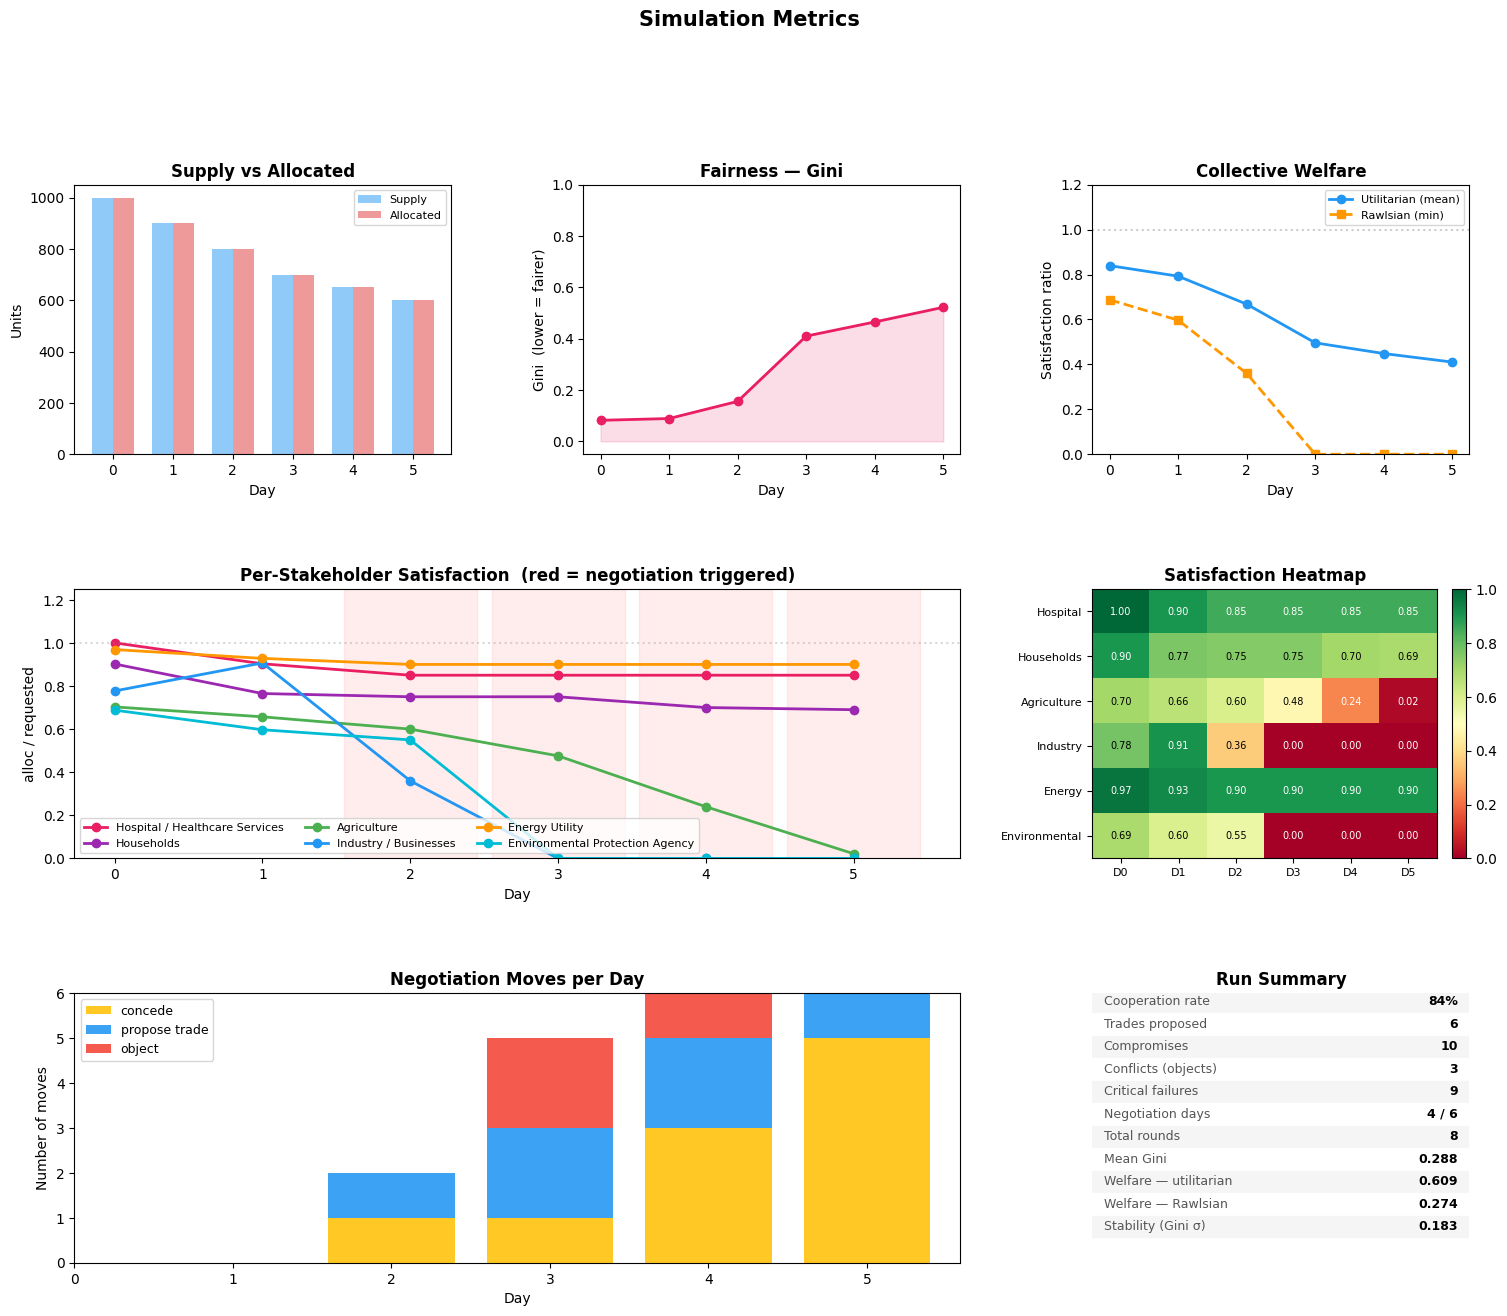

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

STAKEHOLDER_COLORS = {
    "hospital":       "#E91E63",
    "energy_utility": "#FF9800",
    "households":     "#9C27B0",
    "agriculture":    "#4CAF50",
    "industry":       "#2196F3",
    "epa":            "#00BCD4",
}
MOVE_COLORS = {
    "accept":        "#4CAF50",
    "concede":       "#FFC107",
    "propose_trade": "#2196F3",
    "object":        "#F44336",
}

days = sorted(per_run_day["day"].unique())

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Simulation Metrics", fontsize=15, fontweight="bold", y=1.005)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)

# ── 1. Supply vs total allocated ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
day_supply = outcomes_df.groupby("day")[["supply", "total_allocated"]].first()
bw = 0.35
x = np.array(days)
ax1.bar(x - bw/2, day_supply["supply"],          bw, color="#90CAF9", label="Supply")
ax1.bar(x + bw/2, day_supply["total_allocated"], bw, color="#EF9A9A", label="Allocated")
ax1.set_title("Supply vs Allocated", fontweight="bold")
ax1.set_xlabel("Day"); ax1.set_ylabel("Units")
ax1.legend(fontsize=8)

# ── 2. Fairness Gini over time ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(days, per_run_day["fairness_gini"], marker="o", color="#E91E63", linewidth=2)
ax2.fill_between(days, per_run_day["fairness_gini"], alpha=0.15, color="#E91E63")
ax2.set_title("Fairness — Gini", fontweight="bold")
ax2.set_xlabel("Day"); ax2.set_ylabel("Gini  (lower = fairer)")
ax2.set_ylim(-0.05, 1.0)

# ── 3. Collective welfare ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(days, per_run_day["mean_satisfaction"], marker="o",  color="#2196F3",
         linewidth=2, label="Utilitarian (mean)")
ax3.plot(days, per_run_day["min_satisfaction"],  marker="s",  color="#FF9800",
         linewidth=2, linestyle="--", label="Rawlsian (min)")
ax3.axhline(1.0, color="gray", linestyle=":", alpha=0.4)
ax3.set_title("Collective Welfare", fontweight="bold")
ax3.set_xlabel("Day"); ax3.set_ylabel("Satisfaction ratio")
ax3.set_ylim(0, 1.2); ax3.legend(fontsize=8)

# ── 4. Per-stakeholder satisfaction — lines (spans 2 cols) ────────────────
ax4 = fig.add_subplot(gs[1, :2])
for sid in sim.DEMANDER_IDS:
    sdata = outcomes_df[outcomes_df["stakeholder_id"] == sid].set_index("day")["satisfaction"]
    if sdata.empty:
        continue
    ax4.plot(sdata.index, sdata.values, marker="o", linewidth=2,
             label=sim.STAKEHOLDER_BY_ID[sid].name,
             color=STAKEHOLDER_COLORS.get(sid, "gray"))
# shade days where negotiation triggered
for _, row in per_run_day.iterrows():
    if row["severity"]:
        ax4.axvspan(row["day"] - 0.45, row["day"] + 0.45, alpha=0.07, color="red")
ax4.axhline(1.0, color="gray", linestyle=":", alpha=0.3)
ax4.set_title("Per-Stakeholder Satisfaction  (red = negotiation triggered)", fontweight="bold")
ax4.set_xlabel("Day"); ax4.set_ylabel("alloc / requested")
ax4.set_ylim(0, 1.25); ax4.legend(fontsize=8, ncol=3, loc="lower left")

# ── 5. Satisfaction heatmap ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
pivot = (outcomes_df
         .pivot_table(index="stakeholder_id", columns="day",
                      values="satisfaction", aggfunc="mean")
         .reindex(sim.DEMANDER_IDS)
         .dropna(how="all"))
short_names = [sim.STAKEHOLDER_BY_ID[sid].name.split()[0] for sid in pivot.index]
im = ax5.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax5.set_xticks(range(len(pivot.columns)))
ax5.set_xticklabels([f"D{d}" for d in pivot.columns], fontsize=8)
ax5.set_yticks(range(len(pivot.index)))
ax5.set_yticklabels(short_names, fontsize=8)
ax5.set_title("Satisfaction Heatmap", fontweight="bold")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            txt_color = "black" if 0.25 < v < 0.85 else "white"
            ax5.text(j, i, f"{v:.2f}", ha="center", va="center",
                     fontsize=7, color=txt_color)
fig.colorbar(im, ax=ax5, fraction=0.046, pad=0.04)

# ── 6. Negotiation moves per day — stacked bars (spans 2 cols) ────────────
ax6 = fig.add_subplot(gs[2, :2])
moves = decisions_df[decisions_df["event_type"] == "move"]
if not moves.empty:
    move_counts = (moves.groupby(["day", "move_type"])
                        .size().unstack(fill_value=0))
    move_order = [m for m in ["accept", "concede", "propose_trade", "object"]
                  if m in move_counts.columns]
    move_counts = move_counts.reindex(move_order, axis=1, fill_value=0)
    bottom = np.zeros(len(move_counts))
    for mtype in move_order:
        ax6.bar(move_counts.index, move_counts[mtype], bottom=bottom,
                label=mtype.replace("_", " "),
                color=MOVE_COLORS[mtype], alpha=0.88)
        bottom += move_counts[mtype].values
    ax6.set_xticks(days)
else:
    ax6.text(0.5, 0.5, "No negotiation moves recorded",
             ha="center", va="center", transform=ax6.transAxes, color="gray")
ax6.set_title("Negotiation Moves per Day", fontweight="bold")
ax6.set_xlabel("Day"); ax6.set_ylabel("Number of moves")
ax6.legend(fontsize=9, loc="upper left")

# ── 7. Headline summary table ──────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis("off")
s = per_run_summary.iloc[0]
coop = f"{s['cooperation_rate']:.0%}" if not pd.isna(s["cooperation_rate"]) else "—"
rows_t = [
    ("Cooperation rate",      coop),
    ("Trades proposed",       str(int(s["n_trades_proposed"]))),
    ("Compromises",           str(int(s["n_compromises"]))),
    ("Conflicts (objects)",   str(int(s["n_conflicts"]))),
    ("Critical failures",     str(int(s["n_critical_failures"]))),
    ("Negotiation days",      f"{int(s['n_negotiation_days'])} / {int(s['n_days'])}"),
    ("Total rounds",          str(int(s["n_negotiation_rounds_total"]))),
    ("Mean Gini",             f"{s['mean_fairness_gini']:.3f}"),
    ("Welfare — utilitarian", f"{s['mean_collective_welfare_utilitarian']:.3f}"),
    ("Welfare — Rawlsian",    f"{s['mean_collective_welfare_rawlsian']:.3f}"),
    ("Stability (Gini σ)",    f"{s['system_stability_gini_std']:.3f}"),
]
ax7.set_title("Run Summary", fontweight="bold")
n = len(rows_t)
for i, (label, value) in enumerate(rows_t):
    y = 0.97 - i * (0.92 / n)
    bg = "#F5F5F5" if i % 2 == 0 else "white"
    ax7.add_patch(plt.Rectangle((0, y - 0.038), 1, 0.078,
                                  transform=ax7.transAxes, color=bg, zorder=0))
    ax7.text(0.03, y, label,  transform=ax7.transAxes,
             fontsize=9, color="#555", va="center")
    ax7.text(0.97, y, value,  transform=ax7.transAxes,
             fontsize=9, fontweight="bold", va="center", ha="right")

plt.tight_layout()
plt.show()


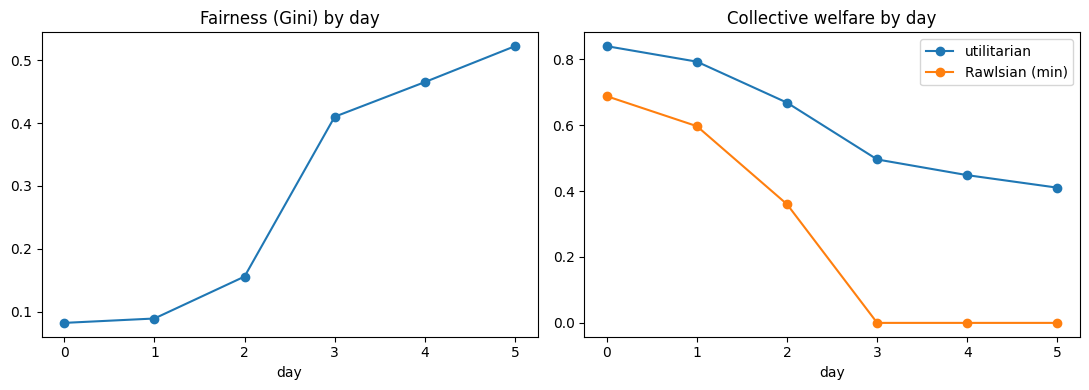

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(per_run_day['day'], per_run_day['fairness_gini'], marker='o')
ax[0].set_title('Fairness (Gini) by day'); ax[0].set_xlabel('day')
ax[1].plot(per_run_day['day'], per_run_day['mean_satisfaction'], marker='o', label='utilitarian')
ax[1].plot(per_run_day['day'], per_run_day['min_satisfaction'], marker='o', label='Rawlsian (min)')
ax[1].set_title('Collective welfare by day'); ax[1].set_xlabel('day'); ax[1].legend()
plt.tight_layout(); plt.show()


---
## 7. Running multiple experimental conditions (`run_batch`)

This is the actual payoff of the `RunConfig`/`decisions_df`/`outcomes_df` contract: define a few conditions, run each across several seeds, and aggregate — without ever touching module constants between runs. `RunConfig` objects themselves are free to build (no API calls), so this first cell runs live with no key required.


In [ ]:
conditions = [
    sim.RunConfig(condition_label='baseline'),
    sim.RunConfig(condition_label='deeper_shortage',
                  supply_schedule=[800, 700, 600, 500, 450, 400]),
    sim.RunConfig(condition_label='hospital_deprioritised',
                  priority_weight_overrides={'hospital': 2.0}),
]
for c in conditions:
    print(f'{c.condition_label:24} n_days={c.n_days}  max_rounds={c.max_rounds}  '
          f'demand_multiplier={c.demand_multiplier}')


`run_batch()` loops conditions × seeds, tags every row with `run_id`/`condition`/`seed`, and concatenates into exactly two dataframes spanning the whole batch. `compute_metrics()` then returns one summary row *per run* — ready for `groupby("condition")`.

**Makes real, billed API calls** — `len(conditions) * n_seeds` full simulations.


In [ ]:
# Uncomment to run live (needs OPENAI_API_KEY):
# batch_decisions, batch_outcomes = sim.run_batch(conditions, n_seeds=5)
# per_run_day, per_run_summary = sim.compute_metrics(batch_outcomes, batch_decisions)
#
# per_run_summary.groupby('condition')[
#     ['mean_fairness_gini', 'mean_collective_welfare_utilitarian',
#      'mean_collective_welfare_rawlsian', 'n_critical_failures', 'cooperation_rate']
# ].agg(['mean', 'std'])   # mean/std ACROSS SEEDS, per condition — the actual research output

if sim.client is None:
    print('OPENAI_API_KEY not set — uncomment the lines above and set your key to run this live.')


`seed` is forwarded to every LLM call in a run (see `llm()` in §1), so re-running the same `RunConfig` with the same seed reproduces the same result, while different seeds genuinely diverge — exactly what a multi-seed convergence check needs, and a feature the original citizen sim only sketched (commented out) without actually wiring up.


---
## 8. Cost tracking


In [ ]:
sim.print_cost_summary()


---
## Notes / open design questions for the next iteration

- Negotiation depth is currently capped at `RunConfig.max_rounds` (default 2); the round-cap outcome is treated as *imposed* if no consensus was reached. Worth checking empirically how often that happens once real runs are in.
- `clear_allocation()` resolves rounding leftovers by trimming the largest allocation; for published results, worth confirming this never silently distorts the headline findings.
- The Water Authority's default priority weights (5/4/3/2/1.5/1, hospital highest) are an explicit normative assumption, not a neutral default — `priority_weight_overrides` makes this a manipulated variable, as in §7's `hospital_deprioritised` condition.
- Reflections don't yet feed back into an explicit `strategy` field — they're retrieved passively like any other memory. If deliberate strategy adaptation (rather than emergent-by-luck recall) matters for the write-up, that's the next mechanism to add.
